In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras.datasets.mnist as mnist
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, log_loss
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from time import time

2026-03-04 20:19:02.244619: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-04 20:19:02.250382: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 20:19:02.583792: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 20:19:03.981567: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train.reshape(60000, -1))
x_test = scaler.transform(x_test.reshape(10000, -1))

indices = np.random.permutation(x_train.shape[0]) # Shuffle the training data
x_train = x_train[indices]
y_train = y_train[indices]

x_validation = x_train[50000:]
y_validation = y_train[50000:]
x_train = x_train[:50000]
y_train = y_train[:50000]

x_validation.shape, y_validation.shape, x_train.shape, y_train.shape, x_test.shape, y_test.shape

((10000, 784), (10000,), (50000, 784), (50000,), (10000, 784), (10000,))

In [3]:
accuracies = {}
losses = {}
timings = {}

## Logistic Regresion Baseline

In [4]:
log_model = LogisticRegression(max_iter=1000)
start_time = time()
log_model.fit(x_train, y_train)
end_time = time()
accuracies['Logistic Regression'] = log_model.score(x_validation, y_validation)
losses['Logistic Regression'] = log_loss(y_validation, log_model.predict_proba(x_validation))
timings['Logistic Regression'] = end_time - start_time
losses

{'Logistic Regression': 0.40471460644788043}

In [5]:
print(classification_report(y_test, log_model.predict(x_test)))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.91      0.89      0.90      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.93      0.93       982
           5       0.89      0.87      0.88       892
           6       0.93      0.94      0.94       958
           7       0.93      0.92      0.92      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



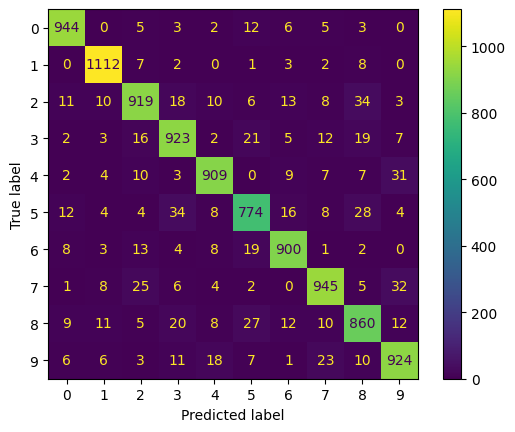

In [6]:

cm = confusion_matrix(y_test, log_model.predict(x_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [7]:
log_model.coef_

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10, 784))

## Neural Network
### Simple Shallow Network

Let's first one-hot encode the target variable. 

In [8]:
from keras.utils import to_categorical

y_val_cat = to_categorical(y_validation, num_classes=10)
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)
y_val_cat.shape, y_train_cat.shape, y_test_cat.shape

((10000, 10), (50000, 10), (10000, 10))

In [9]:
from shallow_nn import ShallowNN

shallow_network = ShallowNN(
    shape=(784,),
    hidden_activation='sigmoid',
    hidden_units=8,
    n_classes=10,
    optimizer='adam'
)

2026-03-04 20:19:53.544064: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │         6,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,370 (24.88 KB)

 Trainable params: 6,370 (24.88 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
start_time = time()
shallow_network.fit(x_train, y_train_cat, epochs=10, validation_data=(x_validation, y_val_cat))
end_time = time()
timings['Shallow NN'] = end_time - start_time

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7959 - loss: 1.0691 - val_accuracy: 0.8576 - val_loss: 0.6585
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 937us/step - accuracy: 0.8723 - loss: 0.5407 - val_accuracy: 0.8763 - val_loss: 0.4845
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8844 - loss: 0.4345 - val_accuracy: 0.8846 - val_loss: 0.4333
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 947us/step - accuracy: 0.8926 - loss: 0.3886 - val_accuracy: 0.8917 - val_loss: 0.4061
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8981 - loss: 0.3626 - val_accuracy: 0.8934 - val_loss: 0.3925
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 942us/step - accuracy: 0.9020 - loss: 0.3460 - val_accuracy: 0.8938 - val_loss: 0.3837
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 937us/step - accuracy: 0.9052 - loss: 0.3334 - val_accuracy: 0.8960 - val_loss: 0.3785
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 944us/step - accuracy: 0.9084 - loss:

In [11]:
metrics = shallow_network.evaluate(x_test, to_categorical(y_test, num_classes=10))
accuracies['Shallow NN'] = metrics['accuracy']
losses['Shallow NN'] = metrics['loss']

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - accuracy: 0.9037 - loss: 0.3450


### Cross Validation using Wandb Sweeps

**Single Run**

In [12]:
from nn_cv import NeuralNetCV, Config

nn1 = NeuralNetCV()

nn1.set_data((x_train, y_train_cat), (x_test, y_test_cat), (x_validation, y_val_cat), num_classes=10)

In [13]:
url, run, nn1_model = nn1.train_once()
url, run

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/subhadeep/.netrc.
wandb: Currently logged in as: cs25mtech15022 (cs25mtech15022-iit-hyderabad) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


{'optimizer': 'sgd', 'epochs': 5, 'learning_rate': 0.001, 'batch_size': 16, 'fc_layer_size': 8, 'fc_layer_depth': 1, 'weight_decay': 0, 'activation': 'sigmoid', 'weight_init': 'uniform'}


accuracy,▁
loss,▁
summary,▁
accuracy,0.5554
loss,1.81966
run,2026-03-04 20:20:27....
summary,0.5554


wandb: WARNING The get_url method is deprecated and will be removed in a future release. Please use `run.url` instead.


(<Sequential name=sequential_1, built=True>,
 'https://wandb.ai/cs25mtech15022-iit-hyderabad/ocr/runs/z3szyghc')

In [14]:
metrics = nn1.evaluate(x_test, y_test_cat)

**Sweep with 20 runs**

In [15]:
config = Config()
config.cv_metric = 'accuracy'
config.cv_goal = 'maximize'
config.activations = ['sigmoid', 'tanh', 'relu']
config.optimizers = ['sgd', 'adam', 'momentum', 'nesterov', 'rmsprop', 'nadam']
config.epochs = [5, 10]
config.learning_rates = [1e-3, 1e-4]
config.batch_sizes = [16, 32, 64]
config.fc_layer_sizes = [32, 64, 128]
config.fc_layer_depths = [3, 4, 5]
config.weight_decays = [0, 0.0005, 0.5]
config.weight_inits = ['uniform', 'glorot_uniform']

nn2 = NeuralNetCV(config)
nn2.set_data((x_train, y_train_cat), (x_test, y_test_cat), (x_validation, y_val_cat), num_classes=10)

In [16]:
start_time = time()
url, sweep, best_run, nn2_model = nn2.train_cv(num_iter=20)
end_time = time()
timings['Deep Neural Net'] = end_time - start_time
url, sweep

Create sweep with ID: 37nlidcm
Sweep URL: https://wandb.ai/cs25mtech15022-iit-hyderabad/ocr/sweeps/37nlidcm


wandb: Agent Starting Run: mhsdg1g5 with config:
wandb: 	activation: relu
wandb: 	batch_size: 64
wandb: 	epochs: 10
wandb: 	fc_layer_depth: 5
wandb: 	fc_layer_size: 32
wandb: 	learning_rate: 0.0001
wandb: 	optimizer: nadam
wandb: 	weight_decay: 0.0005
wandb: 	weight_init: uniform
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/subhadeep/.netrc.


accuracy,▁
loss,▁
summary,▁
accuracy,0.1135
loss,2.30105
run,2026-03-04 20:20:50....
summary,0.1135


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: yg7dpftu with config:
wandb: 	activation: tanh
wandb: 	batch_size: 64
wandb: 	epochs: 10
wandb: 	fc_layer_depth: 4
wandb: 	fc_layer_size: 32
wandb: 	learning_rate: 0.001
wandb: 	optimizer: adam
wandb: 	weight_decay: 0.5
wandb: 	weight_init: uniform
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/subhadeep/.netrc.


accuracy,▁
loss,▁
summary,▁
accuracy,0.1135
loss,2.30108
run,2026-03-04 20:21:18....
summary,0.1135


...

accuracy,▁
loss,▁
summary,▁
accuracy,0.1135
loss,2.66176
run,2026-03-04 20:28:25....
summary,0.1135


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: muj7hplz with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 16
wandb: 	epochs: 10
wandb: 	fc_layer_depth: 4
wandb: 	fc_layer_size: 32
wandb: 	learning_rate: 0.001
wandb: 	optimizer: nadam
wandb: 	weight_decay: 0.5
wandb: 	weight_init: glorot_uniform
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/subhadeep/.netrc.


accuracy,▁
loss,▁
summary,▁
accuracy,0.0974
loss,2.30795
run,2026-03-04 20:29:16....
summary,0.0974


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: ztmiy8ik with config:
wandb: 	activation: relu
wandb: 	batch_size: 64
wandb: 	epochs: 10
wandb: 	fc_layer_depth: 3
wandb: 	fc_layer_size: 128
wandb: 	learning_rate: 0.0001
wandb: 	optimizer: momentum
wandb: 	weight_decay: 0.0005
wandb: 	weight_init: glorot_uniform
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/subhadeep/.netrc.


(<Sequential name=sequential, built=True>, 'r6th40if')

In [17]:
nn2.get_best_config()

{'activation': 'tanh',
 'batch_size': 64,
 'epochs': 10,
 'fc_layer_depth': 3,
 'fc_layer_size': 128,
 'learning_rate': 0.0001,
 'optimizer': 'nadam',
 'weight_decay': 0.0005,
 'weight_init': 'uniform'}

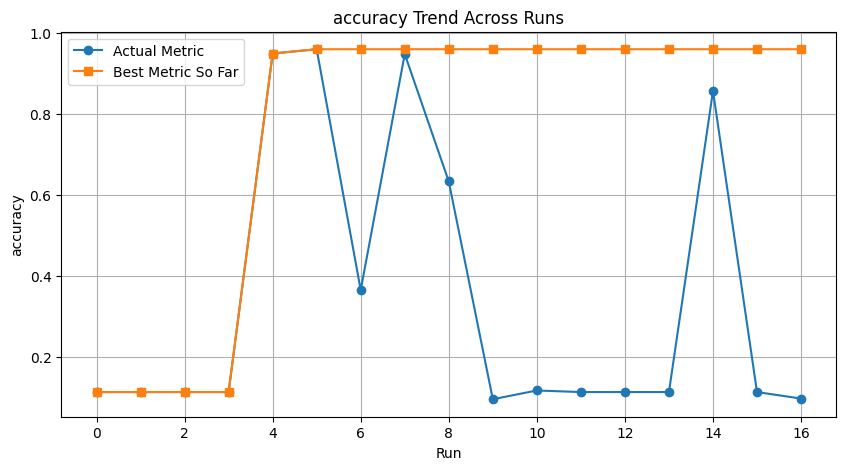

In [18]:
nn2.plot_metric_trend()

In [19]:
metrics = nn2.evaluate(x_test, y_test_cat)
accuracies['Deep Neural Net'] = metrics['accuracy']
losses['Deep Neural Net'] = metrics['loss']

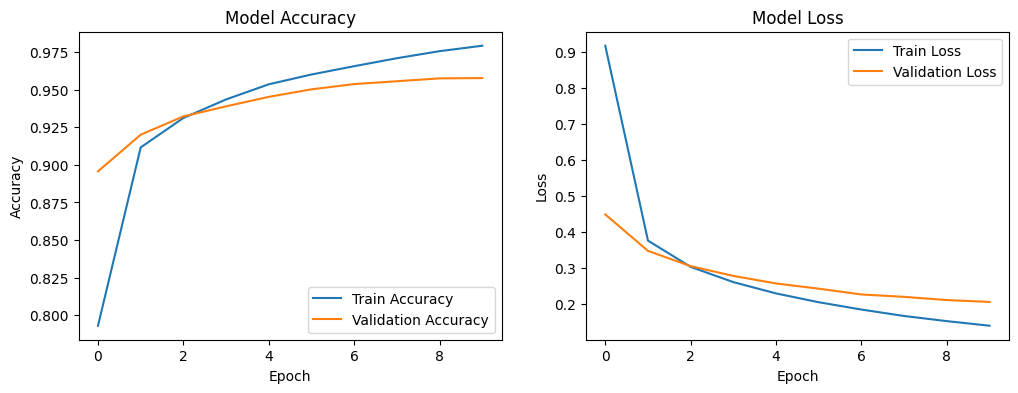

In [20]:
nn2.plot_history()

# Observations

We see that we can get better results by using a neural network over a logistic regression base.

The best hyperparameters are found by using wandb sweeps. Although the time to get said configuration is very high

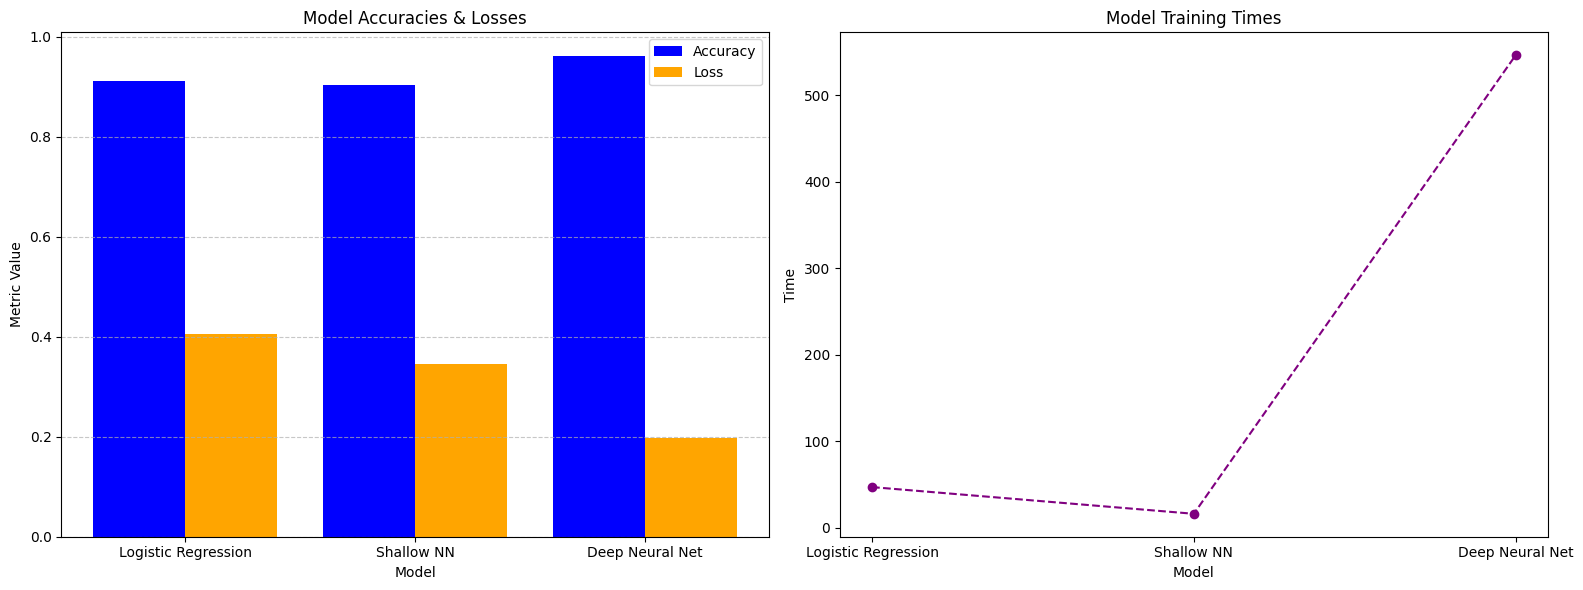

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(3)
width = 0.4
ax1.bar(x - width / 2, list(accuracies.values()), width, color='blue')
ax1.bar(x + width / 2, list(losses.values()), width, color='orange')
ax1.set_title('Model Accuracies & Losses')
ax1.set_ylabel('Metric Value')
ax1.set_xticks(x, list(losses.keys()))
ax1.set_xlabel('Model')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.legend(['Accuracy', 'Loss'])
ax2.plot(list(timings.keys()), list(timings.values()), color='purple', marker='o', linestyle='--')
ax2.set_title('Model Training Times')
ax2.set_ylabel('Time')
ax2.set_xlabel('Model')

plt.tight_layout()
plt.show()